In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('train_data.csv')

C:\Users\Mahyar\AppData\Local\Temp\ipykernel_12872\767949749.py:3: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train_data.csv')


In [10]:
# بررسی مقادیر خالی
missing_reviews = df["reviewText"].isna().sum()
print(f"تعداد مقادیر خالی reviewText: {missing_reviews}")

# محاسبه طول متن (بر حسب تعداد کاراکتر)
df["review_length"] = df["reviewText"].fillna("").str.len()

# آمار توصیفی طول متن
print("\nآمار توصیفی طول متن (تعداد کاراکتر):")
print(df["review_length"].describe().round(2))

تعداد مقادیر خالی reviewText: 0

آمار توصیفی طول متن (تعداد کاراکتر):
count    838944.00
mean        624.69
std         684.13
min         200.00
25%         277.00
50%         408.00
75%         697.00
max       29146.00
Name: review_length, dtype: float64


In [4]:
import arabic_reshaper
from bidi.algorithm import get_display

def fix_farsi(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

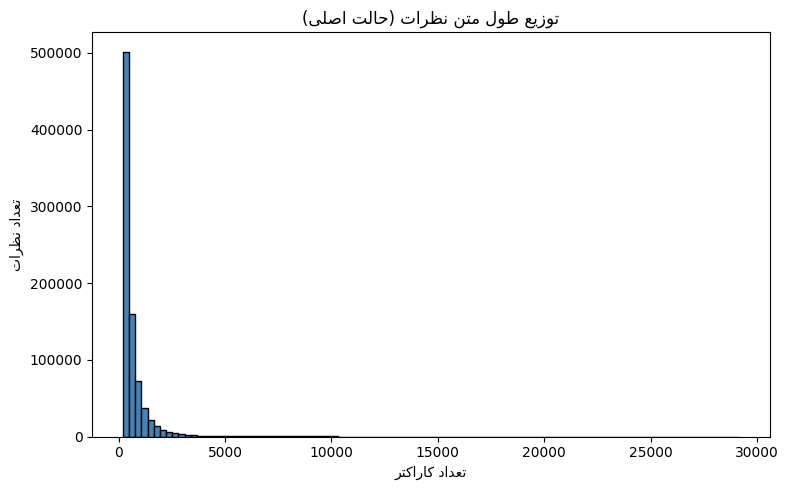

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df['review_length'], bins=100, color='steelblue', edgecolor='black')
plt.title(fix_farsi('توزیع طول متن نظرات (حالت اصلی)'))
plt.xlabel(fix_farsi('تعداد کاراکتر'))
plt.ylabel(fix_farsi('تعداد نظرات'))
plt.tight_layout()
plt.show()

In [13]:
# محاسبه صدک‌های مهم طول متن
percentiles = [50, 75, 90, 95, 99, 99.9]

print("صدک‌های طول متن (تعداد کاراکتر):\n")

for p in percentiles:
    value = df["review_length"].quantile(p / 100)
    print(f"صدک {p:<5}: {value:.0f} کاراکتر")

print(f"\nحداقل طول متن: {df['review_length'].min()} کاراکتر")
print(f"حداکثر طول متن: {df['review_length'].max()} کاراکتر")
print(f"میانگین طول متن: {df['review_length'].mean():.2f} کاراکتر")

صدک‌های طول متن (تعداد کاراکتر):

صدک 50   : 408 کاراکتر
صدک 75   : 697 کاراکتر
صدک 90   : 1217 کاراکتر
صدک 95   : 1733 کاراکتر
صدک 99   : 3399 کاراکتر
صدک 99.9 : 7224 کاراکتر

حداقل طول متن: 200 کاراکتر
حداکثر طول متن: 29146 کاراکتر
میانگین طول متن: 624.69 کاراکتر


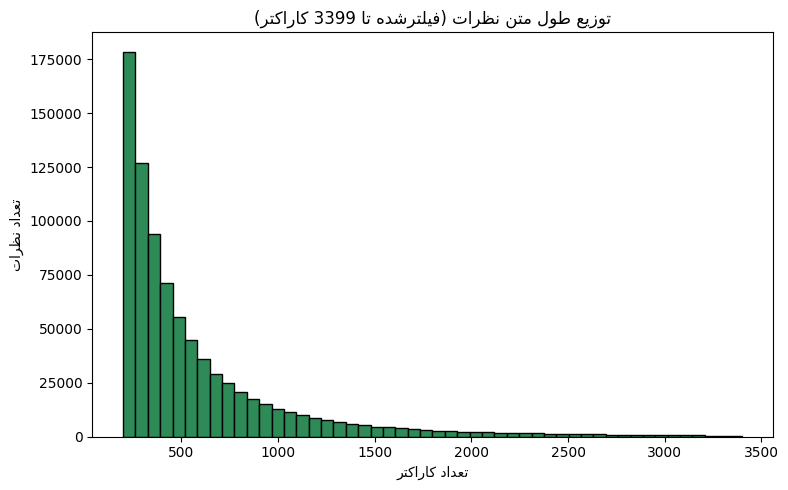

آستانه صدک 99: 3399 کاراکتر
تعداد نظرات حذف‌شده (پرت): 8389
درصد داده‌های حذف‌شده: 1.00%
تعداد نظرات باقی‌مانده: 830555


In [16]:
# حذف داده‌های پرت بر اساس صدک 99
upper_limit = df["review_length"].quantile(0.99)

filtered_df = df[df["review_length"] <= upper_limit].copy()

# رسم هیستوگرام داده‌های فیلترشده
plt.figure(figsize=(8, 5))

plt.hist(
    filtered_df["review_length"],
    bins=50,
    color="seagreen",
    edgecolor="black"
)

plt.title(
    fix_farsi(
        f"توزیع طول متن نظرات (فیلترشده تا {int(upper_limit)} کاراکتر)"
    )
)
plt.xlabel(fix_farsi("تعداد کاراکتر"))
plt.ylabel(fix_farsi("تعداد نظرات"))

plt.tight_layout()
plt.show()

# آمار داده‌های حذف‌شده
removed = len(df) - len(filtered_df)
removed_percent = removed / len(df) * 100

print(f"آستانه صدک 99: {upper_limit:.0f} کاراکتر")
print(f"تعداد نظرات حذف‌شده (پرت): {removed}")
print(f"درصد داده‌های حذف‌شده: {removed_percent:.2f}%")
print(f"تعداد نظرات باقی‌مانده: {len(filtered_df)}")